In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# Mock blob matching the Module 2 data contract
mock_blob = {
    "id": 1,
    "bbox": (100, 100, 50, 20),
    "contour": np.array([[[100, 100]], [[150, 105]], [[145, 120]], [[95, 115]]]), # Slightly angled
    "area_px": 950,
    "polarity": "removed"
}
print("Environment and mock data ready!")

Environment and mock data ready!


Calculated Aspect Ratio: 3.48
Angle of Defect: -84.29 degrees


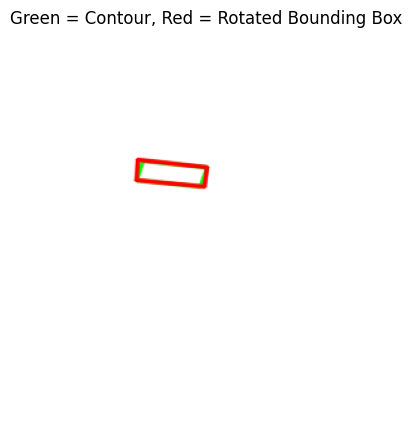

In [3]:
# Extract the contour and area
contour = mock_blob["contour"]
area = mock_blob["area_px"]

# Calculate the rotated bounding box (Practical 8)
rect = cv2.minAreaRect(contour)
(cx, cy), (w, h), angle = rect

# Get oriented dimensions
major_axis = max(w, h)
minor_axis = min(w, h) if min(w, h) > 0 else 1.0
aspect_ratio = major_axis / minor_axis

print(f"Calculated Aspect Ratio: {aspect_ratio:.2f}")
print(f"Angle of Defect: {angle:.2f} degrees")

# Draw it visually to prove it works
blank_canvas = np.ones((300, 300, 3), dtype=np.uint8) * 255

# Draw original contour in green
cv2.drawContours(blank_canvas, [contour], 0, (0, 255, 0), 2, lineType=cv2.LINE_AA)

# Draw rotated bounding box in red
box = cv2.boxPoints(rect)
box = np.intp(box)
cv2.drawContours(blank_canvas, [box], 0, (255, 0, 0), 2, lineType=cv2.LINE_AA)

# Display using matplotlib
plt.figure(figsize=(5, 5))
plt.imshow(blank_canvas)
plt.title("Green = Contour, Red = Rotated Bounding Box")
plt.axis("off")
plt.show()

SSIM Score: 0.9395 (1.0 means perfectly identical)


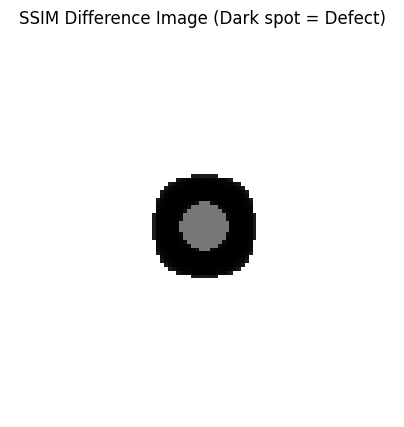

In [4]:
# Create synthetic "Template" and "Test" images
template_board = np.ones((100, 100), dtype=np.uint8) * 200
test_board = template_board.copy()

# Add a "defect" (a dark spot) to the test board
cv2.circle(test_board, (50, 50), 10, (50,), -1)

# Calculate SSIM (Practical 9)
score, diff_image = ssim(template_board, test_board, full=True)

print(f"SSIM Score: {score:.4f} (1.0 means perfectly identical)")

# Display the difference image
plt.figure(figsize=(5, 5))
plt.imshow(diff_image, cmap='gray')
plt.title("SSIM Difference Image (Dark spot = Defect)")
plt.axis("off")
plt.show()